# Stock News Sentiment Analyzer
**CSC 371 — Introduction to NLP — Final Project**

This notebook classifies financial news headlines as **positive / negative / neutral** using a TF-IDF + Logistic Regression pipeline, then compares the resulting sentiment signal against actual stock price movement for 10 tickers.

### Pipeline
1. **Load & preprocess** labeled financial headlines (Financial PhraseBank-style)
2. **Vectorize** text with TF-IDF
3. **Train** a multinomial Logistic Regression classifier
4. **Evaluate** with precision, recall, F1 (per class + macro averages)
5. **Apply** the model to recent headlines for 10 stocks
6. **Compare** aggregated sentiment to price movement using `yfinance`
7. **Visualize** the relationship with `matplotlib`

### Course concepts demonstrated
- Text normalization, tokenization, stopword removal *(Ch 2)*
- TF-IDF vectorization *(Ch 5 / static vector representations)*
- Multinomial Logistic Regression *(Ch 4)*
- Precision / Recall / F-measure evaluation *(Ch 4 §4.7–4.10)*


## 1. Setup — install and import dependencies

In [40]:
# Run once per Colab session. yfinance isn't preinstalled on Colab.
!pip install -q yfinance

In [24]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

import yfinance as yf

# NLTK data
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup complete.")

Setup complete.


## 2. Load the labeled training data
We use the **Financial PhraseBank** dataset (Malo et al., 2014) — ~4.8k English financial news sentences hand-labeled by finance professionals as `positive`, `negative`, or `neutral`. It's hosted on the Hugging Face hub. The datasets library no longer runs the dataset's loading script, so we download the original zip file from the hub and parse the 75%-agreement text file directly.

The dataset comes in four agreement levels (50%, 66%, 75%, 100% annotator agreement). We use the 75%-agreement set (3,453 sentences) for a good balance of size and label quality.

In [41]:
import io
import urllib.request
import zipfile

# Financial PhraseBank — sentences with at least 75% annotator agreement.
# The `datasets` library no longer runs this dataset's loading script, so we
# download the original zip from the Hugging Face hub and parse it directly.
ZIP_URL = ("https://huggingface.co/datasets/takala/financial_phrasebank/"
           "resolve/main/data/FinancialPhraseBank-v1.0.zip")

req = urllib.request.Request(ZIP_URL, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(req) as resp:
    z = zipfile.ZipFile(io.BytesIO(resp.read()))

# Each line is "sentence@label"; the file is latin-1 encoded
name = next(n for n in z.namelist() if n.endswith("Sentences_75Agree.txt"))
rows = []
for line in z.read(name).decode("latin-1").splitlines():
    if "@" in line:
        text, label = line.rsplit("@", 1)
        rows.append((text.strip(), label.strip()))
df = pd.DataFrame(rows, columns=["text", "sentiment"])

print(f"Loaded {len(df)} labeled headlines")
print("\nClass distribution:")
print(df["sentiment"].value_counts())
df.head()

Loaded 3453 labeled headlines

Class distribution:
sentiment
neutral     2146
positive     887
negative     420
Name: count, dtype: int64


,text,sentiment
0,"According to Gran , the company has no plans t...",neutral
1,With the new production plant the company woul...,positive
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,"In the third quarter of 2010 , net sales incre...",positive
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive


## 3. Text preprocessing
Standard NLP pipeline from Ch 2:
- lowercase
- strip URLs, numbers, and punctuation
- tokenize on whitespace
- remove English stopwords
- Porter stem each token

Stemming + stopword removal shrinks the vocabulary so TF-IDF features are more informative.

In [26]:
STOPWORDS = set(stopwords.words("english"))
STEMMER = PorterStemmer()

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)          # URLs
    text = re.sub(r"\d+", " ", text)              # numbers (prices, %s) — sentiment is in words
    text = re.sub(r"[^a-z\s]", " ", text)         # punctuation
    tokens = text.split()
    tokens = [STEMMER.stem(t) for t in tokens if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess)

# Sanity check: see before/after on a few rows
df[["text", "clean_text", "sentiment"]].sample(5, random_state=RANDOM_STATE)

,text,clean_text,sentiment
511,Turnover surged to EUR61 .8 m from EUR47 .6 m ...,turnov surg eur eur due increas servic demand ...,positive
51,In June it sold a 30 percent stake to Nordstje...,june sold percent stake nordstjernan invest gr...,neutral
1886,Aspo 's Group structure and business operation...,aspo group structur busi oper continu develop ...,neutral
765,The device can also be used for theft protecti...,devic also use theft protect posit vehicl boat...,neutral
557,"Of the price , Kesko 's share is 10 mln euro $...",price kesko share mln euro mln recogn gain mln...,positive


## 4. Train/test split, TF-IDF, and Logistic Regression
We use a stratified 80/20 split so each class is represented proportionally in both sets. TF-IDF turns text into sparse weighted-frequency vectors; multinomial Logistic Regression is well-suited to 3-class classification on these features.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["sentiment"],
    test_size=0.20,
    stratify=df["sentiment"],
    random_state=RANDOM_STATE,
)

# TF-IDF: unigrams + bigrams. min_df=2 drops one-off tokens (typos, rare names).
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training vectors:   {X_train_tfidf.shape}")
print(f"Test vectors:       {X_test_tfidf.shape}")
print(f"Vocabulary size:    {len(vectorizer.vocabulary_)}")

Training vectors:   (2762, 5252)
Test vectors:       (691, 5252)
Vocabulary size:    5252


In [28]:
# class_weight="balanced" helps with the neutral-heavy class imbalance
clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    C=1.0,
    random_state=RANDOM_STATE,
)
clf.fit(X_train_tfidf, y_train)
print("Model trained.")

Model trained.


## 5. Evaluation — Precision, Recall, F1
We report per-class and macro-averaged metrics. For an imbalanced 3-class problem like this, macro-F1 is a fairer headline number than plain accuracy, which can be inflated by always guessing "neutral".

In [29]:
y_pred = clf.predict(X_test_tfidf)

print("Classification report")
print("=" * 60)
print(classification_report(y_test, y_pred, digits=3))

prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
print(f"Macro Precision: {prec:.3f}")
print(f"Macro Recall:    {rec:.3f}")
print(f"Macro F1:        {f1:.3f}")

Classification report
              precision    recall  f1-score   support

    negative      0.671     0.679     0.675        84
     neutral      0.886     0.902     0.894       429
    positive      0.769     0.730     0.749       178

    accuracy                          0.831       691
   macro avg      0.775     0.770     0.773       691
weighted avg      0.829     0.831     0.830       691

Macro Precision: 0.775
Macro Recall:    0.770
Macro F1:        0.773


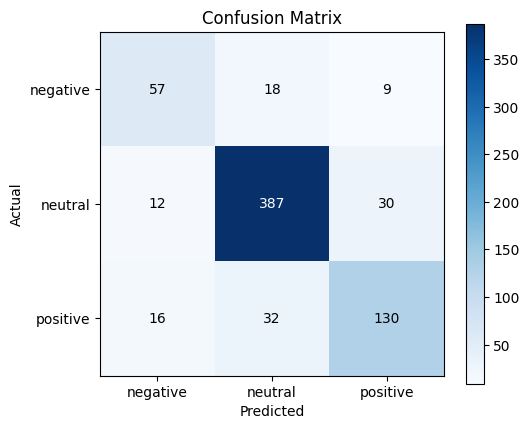

In [30]:
# Confusion matrix as a heatmap
labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### What the model has learned
Inspecting the highest-weighted features per class is a useful sanity check — we should see "good news" words pushing positive and "bad news" words pushing negative.

In [31]:
feature_names = np.array(vectorizer.get_feature_names_out())
for idx, cls in enumerate(clf.classes_):
    top = np.argsort(clf.coef_[idx])[-10:][::-1]
    print(f"Top features for '{cls}': {', '.join(feature_names[top])}")

Top features for 'negative': decreas, fell, drop, lower, declin, decreas eur, profit, compar, neg, strike
Top features for 'neutral': includ, valu, approxim, sale eur, busi, disclos, part, stake, use, complet
Top features for 'positive': increas, rose, improv, grew, sign, posit, said, award, rose eur, expand


## 6. Apply the classifier to recent headlines for 10 tickers
We use `yfinance` to pull recent news headlines for each ticker, then run them through our trained pipeline. Each headline gets a sentiment label, and we aggregate to a single **sentiment score** per ticker:

$$\text{score} = \frac{\#\text{positive} - \#\text{negative}}{\#\text{total headlines}}$$

This gives a value in $[-1, 1]$ that we can compare to price movement.

In [32]:
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META",
           "TSLA", "NVDA", "JPM", "WMT", "DIS"]

def fetch_headlines(ticker: str) -> list[str]:
    """Pull recent headlines for a ticker via yfinance. Schema varies, so be defensive."""
    try:
        items = yf.Ticker(ticker).news or []
    except Exception as e:
        print(f"  {ticker}: news fetch failed ({e})")
        return []
    headlines = []
    for item in items:
        # New schema: item['content']['title']; old schema: item['title']
        title = (item.get("content", {}) or {}).get("title") or item.get("title")
        if title:
            headlines.append(title)
    return headlines

news_data = {t: fetch_headlines(t) for t in TICKERS}
for t, h in news_data.items():
    print(f"{t}: {len(h)} headlines")

AAPL: 10 headlines
MSFT: 10 headlines
GOOGL: 10 headlines
AMZN: 10 headlines
META: 10 headlines
TSLA: 10 headlines
NVDA: 10 headlines
JPM: 10 headlines
WMT: 10 headlines
DIS: 10 headlines


In [38]:
# Save a snapshot of the exact headlines used, so the results can be reproduced
# (yfinance news is live and changes every time). Run this right after fetching.
import os
os.makedirs("data", exist_ok=True)
snapshot = pd.DataFrame(
    [{"ticker": t, "headline": h} for t, hs in news_data.items() for h in hs]
)
snapshot["pulled_on"] = pd.Timestamp.today().date().isoformat()
snapshot.to_csv("data/headlines_snapshot.csv", index=False)
print(f"Saved {len(snapshot)} headlines to data/headlines_snapshot.csv")

try:  # in Colab, also download the file to your computer
    from google.colab import files
    files.download("data/headlines_snapshot.csv")
except ImportError:
    pass

Saved 100 headlines to data/headlines_snapshot.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
def score_headlines(headlines: list[str]) -> dict:
    """Run headlines through the trained pipeline and return label counts + score."""
    if not headlines:
        return {"n": 0, "pos": 0, "neg": 0, "neu": 0, "score": 0.0}
    cleaned = [preprocess(h) for h in headlines]
    vecs = vectorizer.transform(cleaned)
    preds = clf.predict(vecs)
    pos = int((preds == "positive").sum())
    neg = int((preds == "negative").sum())
    neu = int((preds == "neutral").sum())
    n = len(preds)
    return {"n": n, "pos": pos, "neg": neg, "neu": neu, "score": (pos - neg) / n}

sentiment_results = {t: score_headlines(h) for t, h in news_data.items()}
sent_df = pd.DataFrame(sentiment_results).T.reset_index().rename(columns={"index": "ticker"})
sent_df

,ticker,n,pos,neg,neu,score
0,AAPL,10.0,1.0,1.0,8.0,0.0
1,MSFT,10.0,4.0,0.0,6.0,0.4
2,GOOGL,10.0,2.0,0.0,8.0,0.2
3,AMZN,10.0,3.0,1.0,6.0,0.2
4,META,10.0,0.0,0.0,10.0,0.0
5,TSLA,10.0,1.0,2.0,7.0,-0.1
6,NVDA,10.0,1.0,0.0,9.0,0.1
7,JPM,10.0,2.0,1.0,7.0,0.1
8,WMT,10.0,1.0,0.0,9.0,0.1
9,DIS,10.0,1.0,0.0,9.0,0.1


### Sample classified headlines
Eyeballing a few predicted labels per ticker is a good sanity check that the model generalizes from the training corpus to live news headlines.

In [34]:
for t in TICKERS[:3]:  # show first 3 tickers to keep output readable
    headlines = news_data[t]
    if not headlines:
        continue
    print(f"\n=== {t} ===")
    cleaned = [preprocess(h) for h in headlines[:5]]
    preds = clf.predict(vectorizer.transform(cleaned))
    for h, p in zip(headlines[:5], preds):
        print(f"  [{p:>8}] {h[:90]}")


=== AAPL ===
  [ neutral] Apple's new CEO John Ternus plans on making some changes
  [ neutral] OpenAI is releasing newer models faster. Is that a good thing?
  [ neutral] Jim Cramer Says 'Buy' Apple Stock Because of iPhone Duo, Not On Smart Home Device Buzz: Ca
  [ neutral] Apple Predicted To Sell 6 Million iPhone Duo Handsets This Year
  [positive] S&P 500 dips, Nasdaq higher after data shows moderate inflation rise

=== MSFT ===
  [ neutral] AI in America has a huge 1.7 million job shortage problem
  [ neutral] Dow Jones Futures: Micron Earnings Crush Views, S&P 500 At Critical Level As Treasury Yiel
  [ neutral] Microsoft (MSFT) Could Be 21% Above Fair Value After ClickHouse Expansion
  [positive] Was There Any Sign Palantir Stock Would Run?
  [positive] How This Beaten-Down Quantum Stock Could Rise 150%

=== GOOGL ===
  [ neutral] AI companies just signed a White House accord, and tech folks can't get enough of the sign
  [ neutral] AI in America has a huge 1.7 million job shorta

## 7. Compare sentiment to stock price movement
For each ticker, pull the last ~30 days of prices and compute the percent change. Then we plot **sentiment score vs. price change** to see if there's a relationship.

A perfect predictor would show points along a positive-slope line (upper-right and lower-left quadrants). With small headline samples and a 30-day window this is a *very* noisy signal — that noise is part of the discussion.

In [35]:
def pct_change_30d(ticker: str) -> float | None:
    try:
        hist = yf.Ticker(ticker).history(period="1mo")
        if len(hist) < 2:
            return None
        return float((hist["Close"].iloc[-1] / hist["Close"].iloc[0] - 1) * 100)
    except Exception:
        return None

sent_df["pct_change_30d"] = sent_df["ticker"].apply(pct_change_30d)
sent_df

,ticker,n,pos,neg,neu,score,pct_change_30d
0,AAPL,10.0,1.0,1.0,8.0,0.0,2.426717
1,MSFT,10.0,4.0,0.0,6.0,0.4,2.371170
2,GOOGL,10.0,2.0,0.0,8.0,0.2,2.770333
3,AMZN,10.0,3.0,1.0,6.0,0.2,-2.263457
4,META,10.0,0.0,0.0,10.0,0.0,25.445492
5,TSLA,10.0,1.0,2.0,7.0,-0.1,-0.359459
6,NVDA,10.0,1.0,0.0,9.0,0.1,5.148796
7,JPM,10.0,2.0,1.0,7.0,0.1,-6.795330
8,WMT,10.0,1.0,0.0,9.0,0.1,-1.888218
9,DIS,10.0,1.0,0.0,9.0,0.1,-1.242704


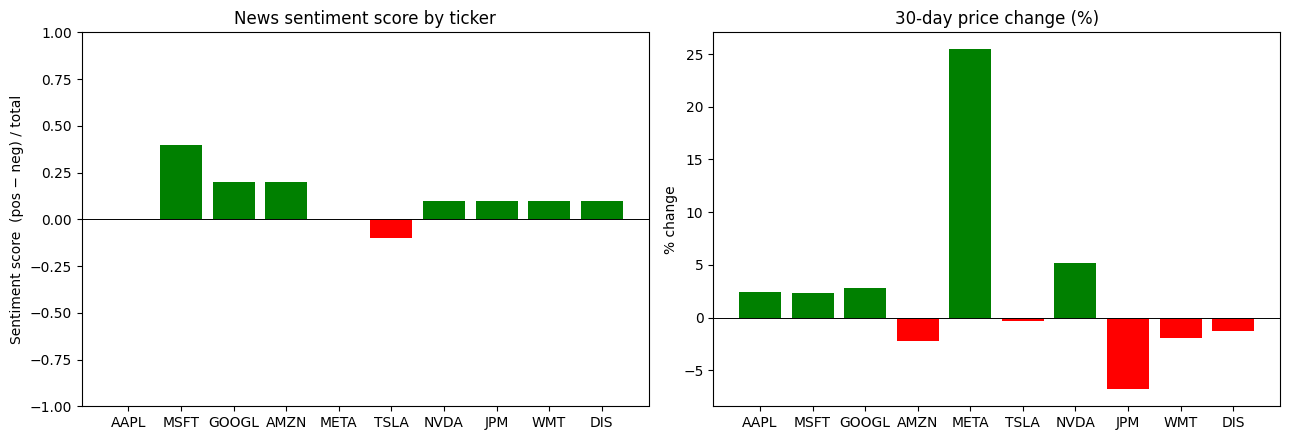

In [36]:
# Side-by-side bar chart: sentiment score vs 30-day % change
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(sent_df["ticker"], sent_df["score"],
            color=["green" if s >= 0 else "red" for s in sent_df["score"]])
axes[0].axhline(0, color="black", linewidth=0.7)
axes[0].set_title("News sentiment score by ticker")
axes[0].set_ylabel("Sentiment score  (pos − neg) / total")
axes[0].set_ylim(-1, 1)

axes[1].bar(sent_df["ticker"], sent_df["pct_change_30d"].fillna(0),
            color=["green" if (v or 0) >= 0 else "red" for v in sent_df["pct_change_30d"]])
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].set_title("30-day price change (%)")
axes[1].set_ylabel("% change")

plt.tight_layout()
plt.show()

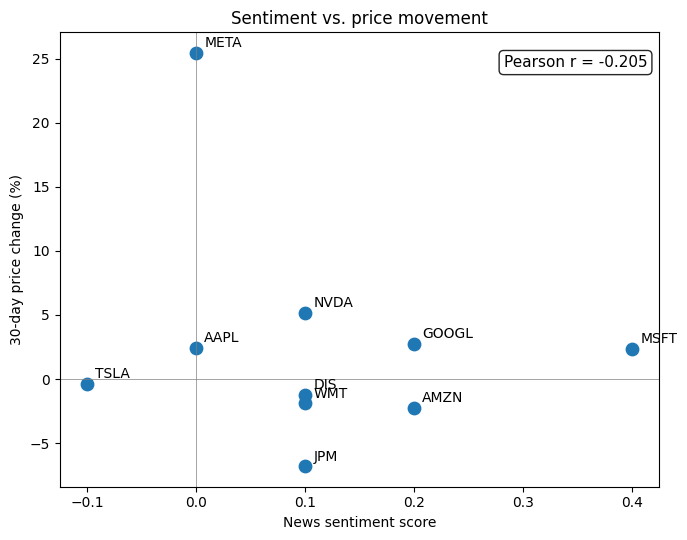

In [39]:
# Scatter + correlation
plot_df = sent_df.dropna(subset=["pct_change_30d"])

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(plot_df["score"], plot_df["pct_change_30d"], s=80)
for _, row in plot_df.iterrows():
    ax.annotate(row["ticker"],
                (row["score"], row["pct_change_30d"]),
                textcoords="offset points", xytext=(6, 4))
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlabel("News sentiment score")
ax.set_ylabel("30-day price change (%)")
ax.set_title("Sentiment vs. price movement")

# Pearson correlation across the 10 tickers
if len(plot_df) >= 3:
    corr = plot_df["score"].corr(plot_df["pct_change_30d"])
    ax.text(0.98, 0.95, f"Pearson r = {corr:.3f}",
            transform=ax.transAxes, fontsize=11, ha="right", va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

plt.tight_layout()
plt.show()

## 8. Discussion & limitations

**What worked**
- TF-IDF + Logistic Regression is a strong, interpretable baseline for financial sentiment, and the top-feature inspection shows the model learned domain-relevant signal (e.g., "profit", "growth", "loss", "decline").
- Macro-F1 is a more honest metric here than accuracy because the dataset skews neutral.

**Limitations**
- **Domain shift.** Financial PhraseBank sentences come from analyst reports; `yfinance` headlines are click-driven journalism. The vocabulary and tone differ.
- **Sample size.** `yfinance` typically returns ~10 recent items per ticker — too few headlines to draw statistical conclusions about any individual stock.
- **Causation vs. correlation.** Even if sentiment and price move together, headlines often *follow* price moves rather than predicting them.
- **Headline-only.** We classify titles, not full articles. Titles are often deliberately ambiguous or sensational.
- **Bag-of-words ceiling.** TF-IDF can't capture negation ("*not* a strong quarter") or context. A contextual model (BERT, covered in Ch 10) would likely do better — a natural extension if time permits.

**Possible extensions**
- Replace TF-IDF + LR with a fine-tuned BERT classifier (Ch 10) and compare F1.
- Aggregate sentiment over a longer window (e.g., 90 days of headlines from a news API) and test predictive power on next-day returns.
- Add a fourth class for "uncertain" / hedged headlines.
